In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib

In [3]:
df = pd.read_csv("realistic_synthetic_well_logs_5000plus.csv")
(df.head())

,DEPTH_ft,GR,RT,RHOB,NPHI,Hydrocarbon,Zone
0,1000,109.88,0.20,2.657,0.300,0,shale
1,1002,110.64,0.20,2.574,0.280,0,shale
2,1004,92.71,4.54,2.446,0.324,0,shale
3,1006,123.09,4.08,2.640,0.307,0,shale
4,1008,124.24,2.02,2.587,0.366,0,shale


In [7]:
df.info()
df.shape
df.columns
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DEPTH_ft     5001 non-null   int64  
 1   GR           5001 non-null   float64
 2   RT           5001 non-null   float64
 3   RHOB         5001 non-null   float64
 4   NPHI         5001 non-null   float64
 5   Hydrocarbon  5001 non-null   int64  
 6   Zone         5001 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 273.6+ KB


,DEPTH_ft,GR,RT,RHOB,NPHI,Hydrocarbon
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,6000.000000,70.468542,61.230688,2.311311,0.218641,0.440312
std,2887.617357,37.318901,75.443161,0.220612,0.118457,0.496474
min,1000.000000,10.440000,0.200000,1.828000,0.000000,0.000000
25%,3500.000000,41.850000,5.630000,2.130000,0.114000,0.000000
50%,6000.000000,59.530000,16.310000,2.301000,0.204000,0.000000
75%,8500.000000,101.280000,110.170000,2.495000,0.314000,1.000000
max,11000.000000,153.980000,304.250000,2.728000,0.465000,1.000000


In [5]:
print(df.isnull().sum())

DEPTH_ft       0
GR             0
RT             0
RHOB           0
NPHI           0
Hydrocarbon    0
Zone           0
dtype: int64


In [6]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)



In [8]:
print(df["Hydrocarbon"].value_counts())


Hydrocarbon
0    2799
1    2202
Name: count, dtype: int64


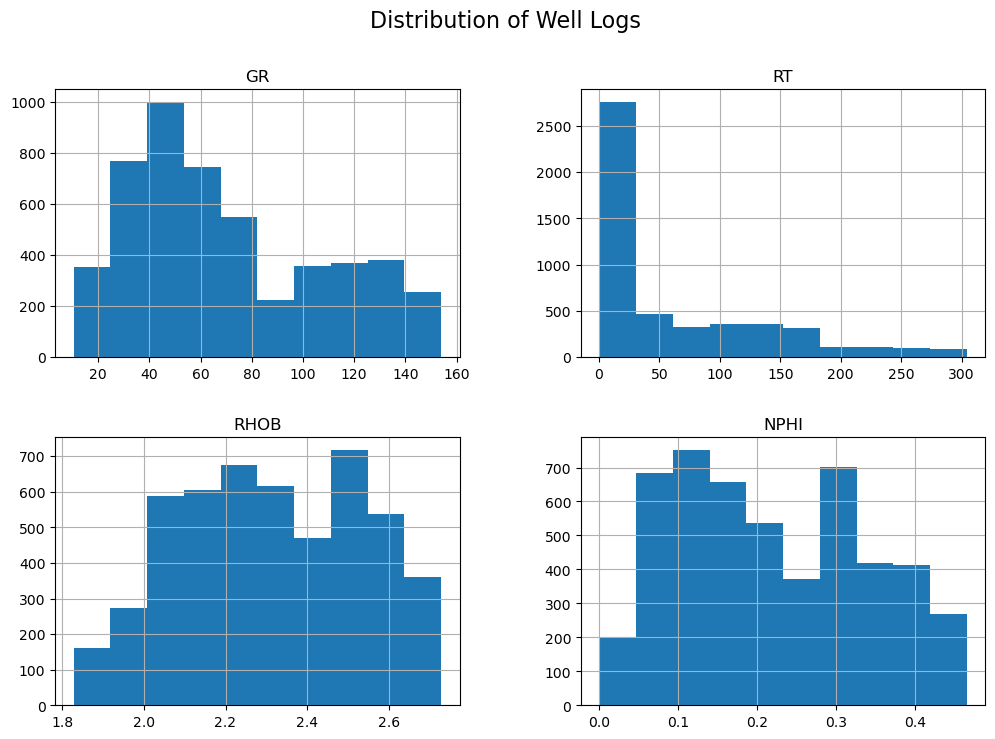

In [13]:
df[["GR", "RT", "RHOB", "NPHI"]].hist( figsize=(12,8))
plt.suptitle("Distribution of Well Logs", fontsize=16)
plt.show()

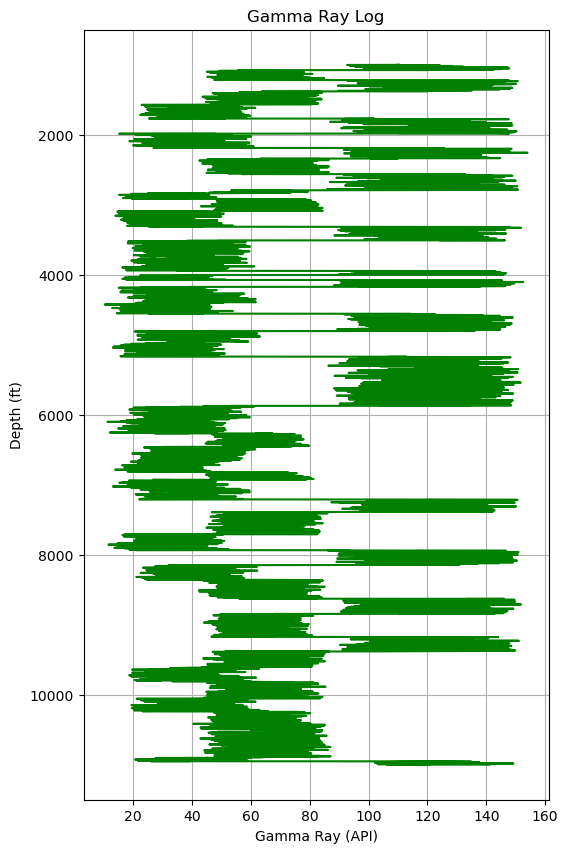

In [16]:
plt.figure(figsize=(6,10))
plt.plot(df["GR"], df["DEPTH_ft"], color="green")
plt.gca().invert_yaxis()
plt.xlabel("Gamma Ray (API)")
plt.ylabel("Depth (ft)")
plt.title("Gamma Ray Log")
plt.grid(True)
plt.show()

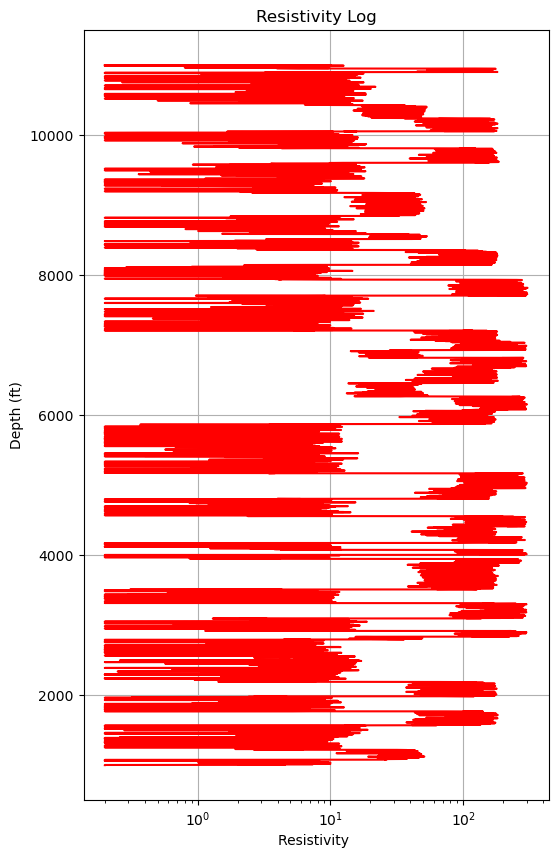

In [19]:
plt.figure(figsize=(6,10))
plt.plot(df["RT"], df["DEPTH_ft"], color="red")
plt.xscale("log")
plt.xlabel("Resistivity ")
plt.ylabel("Depth (ft)")
plt.title("Resistivity Log")
plt.grid(True)
plt.show()

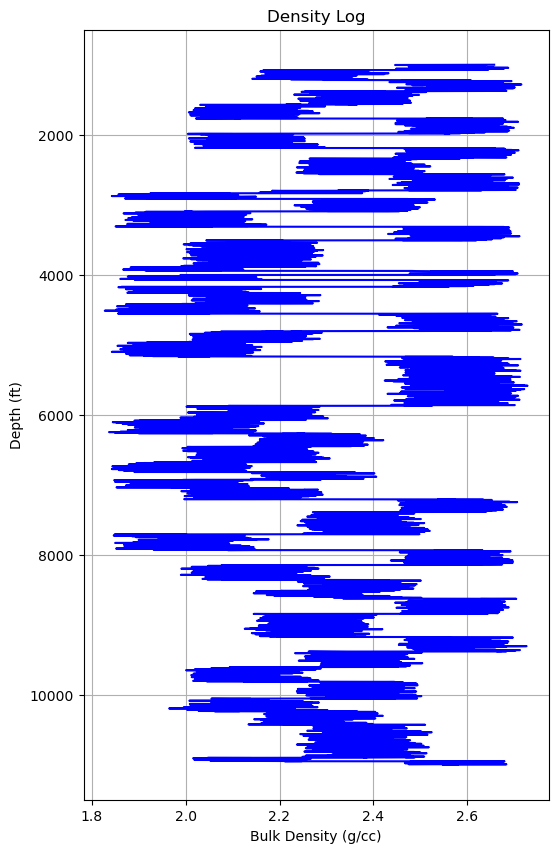

In [20]:
plt.figure(figsize=(6,10))
plt.plot(df["RHOB"], df["DEPTH_ft"], color="blue")
plt.gca().invert_yaxis()
plt.xlabel("Bulk Density (g/cc)")
plt.ylabel("Depth (ft)")
plt.title("Density Log")
plt.grid(True)
plt.show()

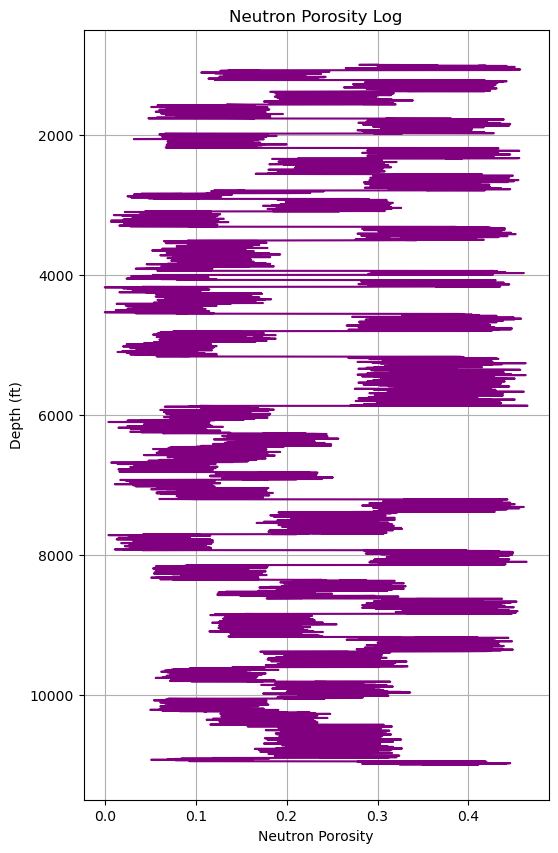

In [21]:
plt.figure(figsize=(6,10))
plt.plot(df["NPHI"], df["DEPTH_ft"], color="purple")
plt.gca().invert_yaxis()
plt.xlabel("Neutron Porosity")
plt.ylabel("Depth (ft)")
plt.title("Neutron Porosity Log")
plt.grid(True)
plt.show()

In [23]:
X = df[["GR", "RT", "RHOB", "NPHI"]]
y = df["Hydrocarbon"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=4, stratify=y)
print(f"Training Samples :{X_train.shape}")
print(f"Testing Samples :{ X_test.shape}")

Training Samples :(4000, 4)
Testing Samples :(1001, 4)


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
joblib.dump(scaler, "scaler_cnn.pkl")

['scaler_cnn.pkl']

In [44]:
model = Sequential([
Dense(units=64,activation='relu', input_shape=(4,)),
Dropout(0.30),
Dense(units=32,activation='relu'),
Dropout(0.30),
Dense(units=16,activation='relu'),
Dense(units=1,activation='sigmoid')])

C:\Users\indra\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(optimizer='adam',
loss='binary_crossentropy',metrics=['accuracy'])

In [48]:
early_stop = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [50]:
train = model.fit(X_train_scaled,y_train,validation_split=0.20,epochs=100,batch_size=32,callbacks=[early_stop], verbose=1)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9475 - loss: 0.0926 - val_accuracy: 0.9488 - val_loss: 0.0897
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9494 - loss: 0.0916 - val_accuracy: 0.9500 - val_loss: 0.0901
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9525 - loss: 0.0900 - val_accuracy: 0.9475 - val_loss: 0.0895
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9509 - loss: 0.0896 - val_accuracy: 0.9488 - val_loss: 0.0888
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9522 - loss: 0.0886 - val_accuracy: 0.9500 - val_loss: 0.0876
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9516 - loss: 0.0897 - val_accuracy: 0.9538 - val_loss: 0.0888
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9494 - loss: 0.0883 - val_accuracy: 0.9538 - val_loss: 0.0883
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9478 - loss: 0.0873 - val_accu

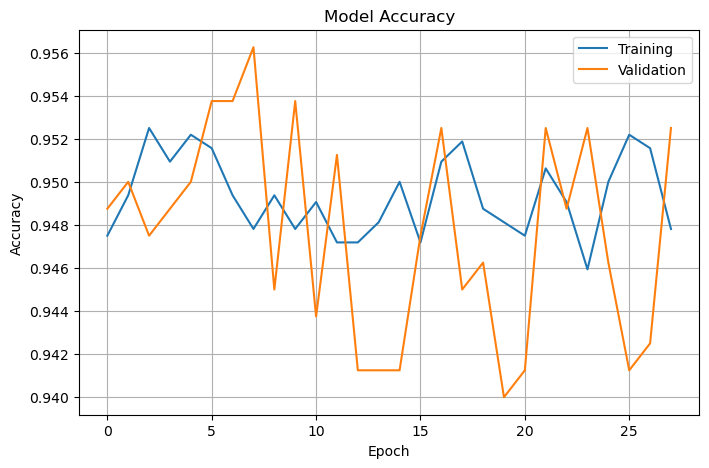

In [51]:
plt.figure(figsize=(8,5))
plt.plot(train.history['accuracy'])
plt.plot(train.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.grid()
plt.show()

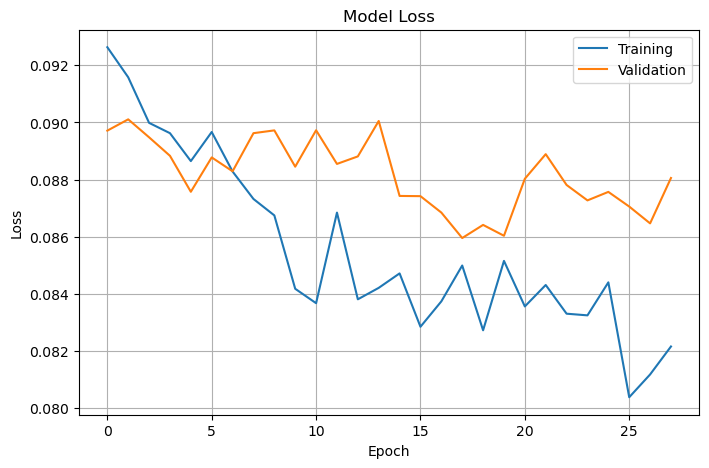

In [52]:
plt.figure(figsize=(8,5))
plt.plot(train.history['loss'])
plt.plot(train.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training","Validation"])
plt.grid()
plt.show()

In [55]:
loss, accuracy = model.evaluate( X_test_scaled,y_test)
print(f"Loss :{ loss}")
print(f"Accuracy : {accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9391 - loss: 0.0859  
Loss :0.08588571846485138
Accuracy : 0.9390609264373779


In [60]:
print(accuracy_score( y_test,predictions))

0.939060939060939


In [64]:
matrix = confusion_matrix(y_test,predictions)
print(matrix)

[[531  29]
 [ 32 409]]


In [65]:
model.save("hydrocarbon_prediction_model.keras")